# Training vs Generated Data Analysis

Compares aggregate statistics, distributions and temporal structure between:
- **Reference**: the first `TRAINING_DATASET_SIZE` CSVs from the training directory (sorted)
- **Generated**: all CSVs produced by the reverse-diffusion model

Both datasets are either log-prices or log-returns.
Reference paths may be full-length stock histories; generated paths are fixed-length windows.

In [49]:
# ── USER INPUTS ───────────────────────────────────────────────────────────────
REF_DIRECTORY         = "../data/replication_returns_other"          # training data folder
GEN_DIRECTORY         = "../data/generated/replication/HEUN_ODE_NO_NO_REPL_RET_OTHER_UNCO_ep-500_sde-ve_noise-exponential_20260421_162722"
SEED                  = 42
TRAINING_SEED         = 42    # must match config["train"]["seed"] used during training
VAL_SPLIT_RATIO       = 0.1  # set to e.g. 0.1 if --val_split_ratio was used; else None
TRAINING_DATASET_SIZE = None   # number of sliding windows — mirrors --train_subset_size
                               # set to None to use all available (post-val) windows
SEQ_LEN               = 2048  # window length used during training (--seq_len)
STRIDE                = 400   # stride used during training (--stride)
# ─────────────────────────────────────────────────────────────────────────────

In [50]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats as scipy_stats
from statsmodels.tsa.stattools import acf as sm_acf

np.random.seed(SEED)
rng = np.random.default_rng(SEED)

print(f"REF_DIRECTORY         : {REF_DIRECTORY}")
print(f"GEN_DIRECTORY         : {GEN_DIRECTORY}")
print(f"SEED                  : {SEED}")
print(f"TRAINING_DATASET_SIZE : {TRAINING_DATASET_SIZE}")
print(f"SEQ_LEN               : {SEQ_LEN}")
print(f"STRIDE                : {STRIDE}")

REF_DIRECTORY         : ../data/replication_returns_other
GEN_DIRECTORY         : ../data/generated/replication/HEUN_ODE_NO_NO_REPL_RET_OTHER_UNCO_ep-500_sde-ve_noise-exponential_20260421_162722
SEED                  : 42
TRAINING_DATASET_SIZE : None
SEQ_LEN               : 2048
STRIDE                : 400


## 1. Load data

In [51]:
# ── Reference data ────────────────────────────────────────────────────────────
# Mirrors csdi_train_modified.py exactly:
#   1. Load ALL sorted CSVs — no file cap
#   2. Extract sliding windows with same SEQ_LEN / STRIDE / drop_incomplete=True
#   3. Replicate torch.randperm(seed) + val split + train_subset_size
import torch

ref_csv_files = sorted(Path(REF_DIRECTORY).glob("*.csv"))
if len(ref_csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in: {REF_DIRECTORY}")

all_windows: list[np.ndarray] = []
n_skipped_short = 0
for fp in ref_csv_files:
    series = pd.read_csv(fp)["log_adj_close"].values.astype(np.float64)
    T = len(series)
    max_start = T - SEQ_LEN
    if max_start < 0:   # shorter than SEQ_LEN — skip (drop_incomplete=True)
        n_skipped_short += 1
        continue
    for s in range(0, max_start + 1, STRIDE):
        all_windows.append(series[s : s + SEQ_LEN])

if n_skipped_short:
    print(f"[WARNING] {n_skipped_short} file(s) shorter than SEQ_LEN={SEQ_LEN} were skipped.")
if len(all_windows) == 0:
    raise RuntimeError("No windows could be extracted. Check SEQ_LEN / STRIDE / REF_DIRECTORY.")

print(f"Total windows in full dataset : {len(all_windows)} "
      f"(from {len(ref_csv_files) - n_skipped_short} usable file(s), "
      f"SEQ_LEN={SEQ_LEN}, STRIDE={STRIDE})")

# ── Replicate training subset selection with torch RNG ────────────────────────
torch_rng  = torch.Generator().manual_seed(TRAINING_SEED)
all_indices = torch.randperm(len(all_windows), generator=torch_rng).tolist()

# Carve out val split first (mirrors val_split_ratio logic in training script)
if VAL_SPLIT_RATIO is not None:
    val_size   = max(1, int(len(all_windows) * VAL_SPLIT_RATIO))
    train_pool = all_indices[val_size:]
    print(f"Val split : {val_size} windows held out (VAL_SPLIT_RATIO={VAL_SPLIT_RATIO})")
else:
    train_pool = all_indices

# Then take TRAINING_DATASET_SIZE from the remaining pool
if TRAINING_DATASET_SIZE is not None and TRAINING_DATASET_SIZE < len(train_pool):
    train_indices = train_pool[:TRAINING_DATASET_SIZE]
    print(f"Reference : {len(train_indices)} windows "
          f"(TRAINING_DATASET_SIZE={TRAINING_DATASET_SIZE} of {len(train_pool)} in pool)")
else:
    train_indices = train_pool
    if TRAINING_DATASET_SIZE is not None:
        print(f"[WARNING] TRAINING_DATASET_SIZE={TRAINING_DATASET_SIZE} >= pool size "
              f"({len(train_pool)}); using all pool windows.")
    print(f"Reference : {len(train_indices)} windows (full training pool)")

ref_paths = [all_windows[i] for i in train_indices]

assert all(len(w) == SEQ_LEN for w in ref_paths), "Window length mismatch — check SEQ_LEN"
print(f"  All window lengths = {SEQ_LEN}  ✓")

Total windows in full dataset : 5568 (from 210 usable file(s), SEQ_LEN=2048, STRIDE=400)
Val split : 556 windows held out (VAL_SPLIT_RATIO=0.1)
Reference : 5012 windows (full training pool)
  All window lengths = 2048  ✓


In [52]:
# ── Generated data ────────────────────────────────────────────────────────────
# Load ALL CSV files in GEN_DIRECTORY (no size cap).
# Two formats are supported:
#   (a) Per-sample CSVs  — columns: date, log_adj_close  (one file per path)
#   (b) Wide-format CSV  — columns: sample_idx, start_date, end_date, step_000, step_001, ...
#       (produced by generate_samples.py as "generated_samples.csv")
gen_csv_files = sorted(Path(GEN_DIRECTORY).glob("*.csv"))

if len(gen_csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in: {GEN_DIRECTORY}")

gen_paths: list[np.ndarray] = []
skipped = 0
for fp in gen_csv_files:
    df = pd.read_csv(fp)
    if "log_adj_close" in df.columns:
        # Format (a): individual per-sample CSV
        gen_paths.append(df["log_adj_close"].values.astype(np.float64))
    else:
        # Format (b): wide-format — each row is one sample path
        step_cols = sorted([c for c in df.columns if c.startswith("step_")])
        if step_cols:
            for _, row in df.iterrows():
                gen_paths.append(row[step_cols].values.astype(np.float64))
        else:
            skipped += 1

if skipped:
    print(f"[WARNING] Skipped {skipped} file(s) with unrecognised column layout.")
if len(gen_paths) == 0:
    raise RuntimeError("No valid generated paths could be loaded from GEN_DIRECTORY.")

gen_lens = [len(p) for p in gen_paths]
print(f"Generated: {len(gen_paths)} paths loaded  ({len(gen_csv_files)} CSV file(s) read)")
print(f"  Path lengths — min={min(gen_lens)}  max={max(gen_lens)}  "
      f"median={int(np.median(gen_lens))}")

Generated: 1048 paths loaded  (1 CSV file(s) read)
  Path lengths — min=2048  max=2048  median=2048


## 2. Aggregate statistics

In [53]:
def compute_stats(paths: list[np.ndarray], label: str) -> dict:
    flat = np.concatenate(paths)
    incs = np.concatenate([np.diff(p) for p in paths if len(p) > 1])
    return {
        "label"            : label,
        "n_paths"          : len(paths),
        "n_values"         : len(flat),
        "mean"             : flat.mean(),
        "std"              : flat.std(),
        "min"              : flat.min(),
        "q01"              : np.quantile(flat, 0.01),
        "q05"              : np.quantile(flat, 0.05),
        "q25"              : np.quantile(flat, 0.25),
        "q50"              : np.quantile(flat, 0.50),
        "q75"              : np.quantile(flat, 0.75),
        "q95"              : np.quantile(flat, 0.95),
        "q99"              : np.quantile(flat, 0.99),
        "max"              : flat.max(),
        "skewness"         : scipy_stats.skew(flat),
        "excess_kurtosis"  : scipy_stats.kurtosis(flat, fisher=True),
        "inc_mean"         : incs.mean(),
        "inc_std"          : incs.std(),
        "inc_min"          : incs.min(),
        "inc_q01"          : np.quantile(incs, 0.01),
        "inc_q99"          : np.quantile(incs, 0.99),
        "inc_max"          : incs.max(),
        "inc_skewness"     : scipy_stats.skew(incs),
        "inc_excess_kurt"  : scipy_stats.kurtosis(incs, fisher=True),
    }

ref_stats = compute_stats(ref_paths, "Reference (training)")
gen_stats = compute_stats(gen_paths, "Generated")

# ── Levels table ──────────────────────────────────────────────────────────────
level_keys = ["n_paths", "n_values", "mean", "std", "min", "q01", "q05",
              "q25", "q50", "q75", "q95", "q99", "max", "skewness", "excess_kurtosis"]
df_levels = pd.DataFrame(
    {k: {"Reference": ref_stats[k], "Generated": gen_stats[k]} for k in level_keys}
).T.round(4)

print("=" * 60)
print("  LOG_ADJ_CLOSE  —  Aggregate statistics (levels)")
print("=" * 60)
display(df_levels.style.format("{:.4f}"))

  LOG_ADJ_CLOSE  —  Aggregate statistics (levels)


,Reference,Generated
n_paths,5012.0000,1048.0000
n_values,10264576.0000,2146304.0000
mean,0.0005,0.0005
std,0.0209,0.0225
min,-0.9363,-0.8591
q01,-0.0564,-0.0581
q05,-0.0292,-0.0327
q25,-0.0086,-0.0114
q50,0.0000,0.0004
q75,0.0095,0.0123


In [54]:
# ── Increments table ──────────────────────────────────────────────────────────
inc_keys = ["inc_mean", "inc_std", "inc_min", "inc_q01", "inc_q99",
            "inc_max", "inc_skewness", "inc_excess_kurt"]
rename = {
    "inc_mean": "mean", "inc_std": "std", "inc_min": "min",
    "inc_q01": "q01", "inc_q99": "q99", "inc_max": "max",
    "inc_skewness": "skewness", "inc_excess_kurt": "excess_kurtosis",
}
df_incs = pd.DataFrame(
    {rename[k]: {"Reference": ref_stats[k], "Generated": gen_stats[k]}
     for k in inc_keys}
).T.round(6)

print("=" * 60)
print("  INCREMENTS  ΔX_t = X_t − X_{t−1}  —  Aggregate statistics")
print("=" * 60)
display(df_incs.style.format("{:.4f}"))

  INCREMENTS  ΔX_t = X_t − X_{t−1}  —  Aggregate statistics


,Reference,Generated
mean,0.0000,0.0000
std,0.0298,0.0319
min,-1.3863,-0.8419
q01,-0.0810,-0.0839
q99,0.0825,0.0841
max,1.0291,0.8941
skewness,0.2576,0.0214
excess_kurtosis,26.6200,10.1021


## Per-window statistics

Per-window statistics — summary (mean ± std across windows)


,Reference mean,Reference std,Generated mean,Generated std
mean,0.0005,0.0004,0.0005,0.0004
std,0.0197,0.0070,0.0216,0.0062
skewness,-0.3372,1.3633,-0.1829,0.6092
excess_kurt,14.0467,36.5049,6.2544,10.2334
zero_ratio,0.0720,0.0939,0.0000,0.0000
inc_std,0.0280,0.0101,0.0307,0.0089
inc_skewness,0.2363,0.5029,0.0253,0.1929
inc_excess_kurt,11.2118,23.0610,4.2615,6.3999


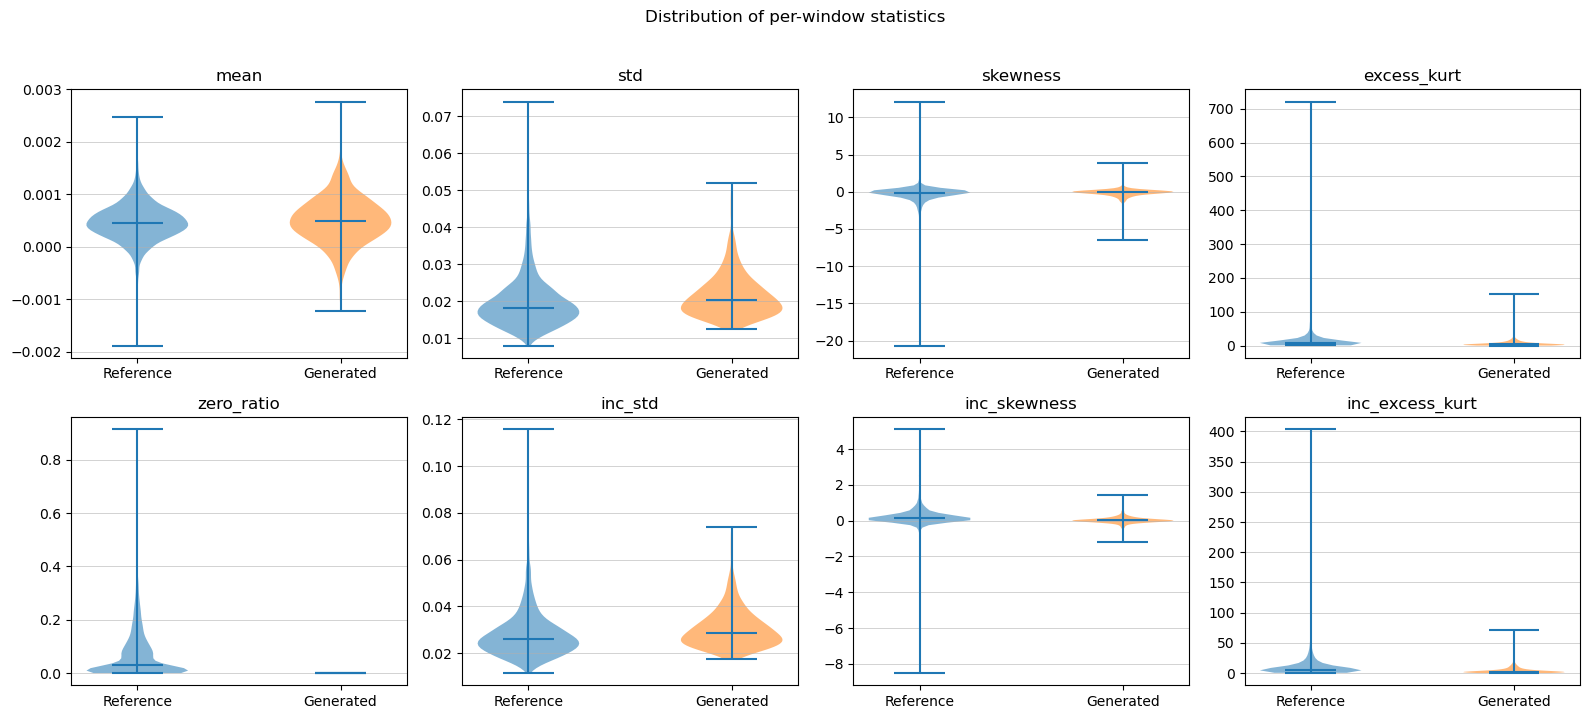

In [ ]:
def per_window_stats(paths: list[np.ndarray]) -> pd.DataFrame:
    rows = []
    for p in paths:
        incs = np.diff(p)
        rows.append({
            "mean"         : float(p.mean()),
            "std"          : float(p.std()),
            "skewness"     : float(scipy_stats.skew(p)),
            "excess_kurt"  : float(scipy_stats.kurtosis(p, fisher=True)),
            "zero_ratio"   : float(np.mean(p == 0.0)),
            "inc_std"      : float(incs.std()),
            "inc_skewness" : float(scipy_stats.skew(incs)),
            "inc_excess_kurt": float(scipy_stats.kurtosis(incs, fisher=True)),
        })
    return pd.DataFrame(rows)

ref_pw = per_window_stats(ref_paths)
gen_pw = per_window_stats(gen_paths)

# ── Summary table: mean ± std of each per-window stat ────────────────────────
summary = pd.DataFrame({
    "Reference  mean": ref_pw.mean(),
    "Reference  std" : ref_pw.std(),
    "Generated  mean": gen_pw.mean(),
    "Generated  std" : gen_pw.std(),
}).round(5)
print("Per-window statistics — summary (mean ± std across windows)")
display(summary.style.format("{:.4f}"))

# ── Violin plots ──────────────────────────────────────────────────────────────
metrics = list(ref_pw.columns)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, metric in zip(axes.flat, metrics):
    data  = [ref_pw[metric].values, gen_pw[metric].values]
    parts = ax.violinplot(data, positions=[0, 1], showmedians=True, showextrema=True)
    parts["bodies"][0].set_facecolor("tab:blue");   parts["bodies"][0].set_alpha(0.55)
    parts["bodies"][1].set_facecolor("tab:orange"); parts["bodies"][1].set_alpha(0.55)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Reference", "Generated"])
    ax.set_title(metric)
    ax.grid(axis="y", linewidth=0.4)

plt.suptitle("Distribution of per-window statistics", y=1.02)
plt.tight_layout()
plt.show()


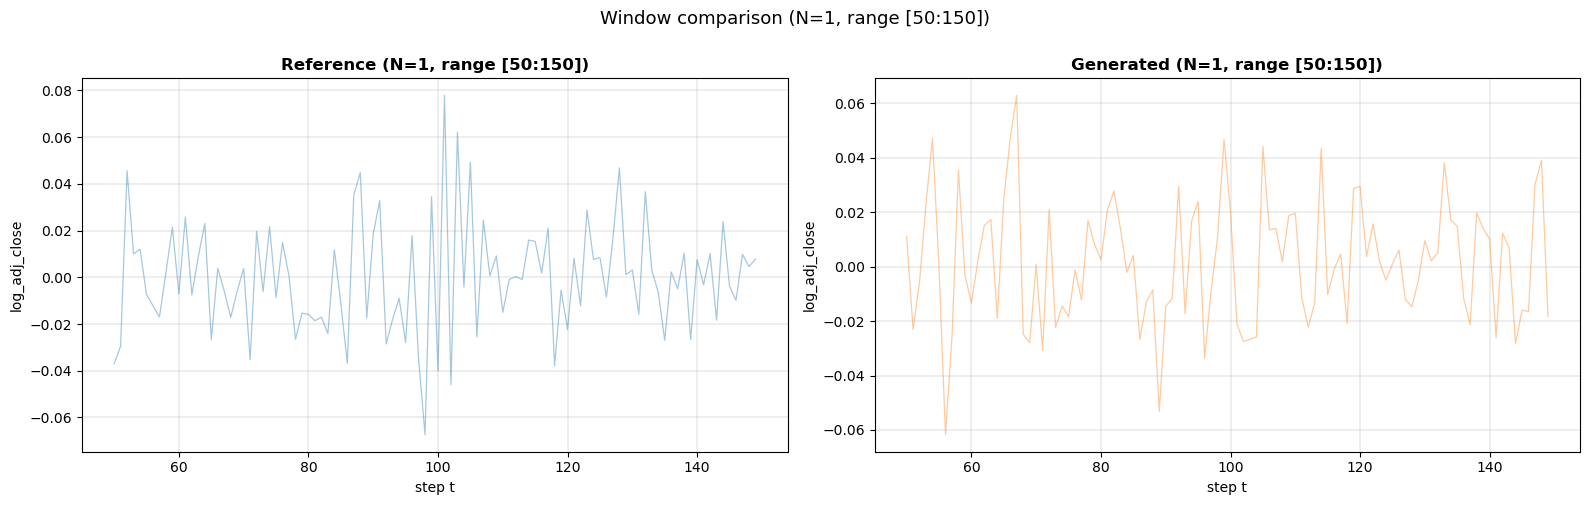

Plotted 1 reference and 1 generated paths
Range: [50:150]


In [73]:
# ── Compare N individual windows with custom range (user-specified) ──────────
N_WINDOWS = 1     # ← change this to select how many paths to visualize
START_IDX = 50       # ← start index (0 = beginning)
END_IDX   = 150   # ← end index (None = full length, or e.g. 500, 1000, etc.)

n_ref = min(N_WINDOWS, len(ref_paths))
n_gen = min(N_WINDOWS, len(gen_paths))

ref_idx = rng.choice(len(ref_paths), size=n_ref, replace=False)
gen_idx = rng.choice(len(gen_paths), size=n_gen, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Reference paths ─────────────────────────────────────────────────────────
ax = axes[0]
for i in ref_idx:
    p = ref_paths[i][START_IDX:END_IDX]
    ax.plot(np.arange(START_IDX, START_IDX + len(p)), p, 
            alpha=0.4, linewidth=0.9, color="tab:blue")
ax.set_title(f"Reference (N={n_ref}, range [{START_IDX}:{END_IDX}])", 
             fontsize=12, fontweight="bold")
ax.set_xlabel("step t")
ax.set_ylabel("log_adj_close")
ax.grid(True, linewidth=0.3)

# ── Generated paths ─────────────────────────────────────────────────────────
ax = axes[1]
for i in gen_idx:
    p = gen_paths[i][START_IDX:END_IDX]
    ax.plot(np.arange(START_IDX, START_IDX + len(p)), p, 
            alpha=0.4, linewidth=0.9, color="tab:orange")
ax.set_title(f"Generated (N={n_gen}, range [{START_IDX}:{END_IDX}])", 
             fontsize=12, fontweight="bold")
ax.set_xlabel("step t")
ax.set_ylabel("log_adj_close")
ax.grid(True, linewidth=0.3)

plt.suptitle(f"Window comparison (N={N_WINDOWS}, range [{START_IDX}:{END_IDX}])", 
             y=1.00, fontsize=13)
plt.tight_layout()
plt.show()

print(f"Plotted {n_ref} reference and {n_gen} generated paths")
print(f"Range: [{START_IDX}:{END_IDX}]")


## 3. Level distribution: histogram, QQ plot, ECDF

Levels KS statistic = 0.0530  |  p-value = 0.0000e+00


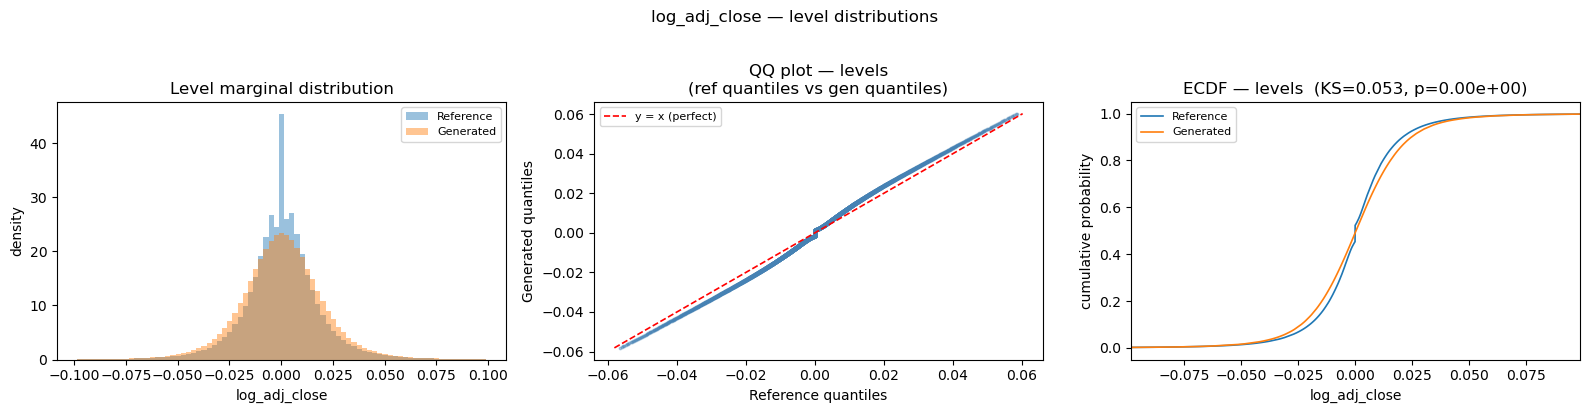

In [56]:
ref_flat = np.concatenate(ref_paths)
gen_flat = np.concatenate(gen_paths)

ks_stat_lev, ks_p_lev = scipy_stats.ks_2samp(ref_flat, gen_flat)
print(f"Levels KS statistic = {ks_stat_lev:.4f}  |  p-value = {ks_p_lev:.4e}")

combined = np.concatenate([ref_flat, gen_flat])
lo, hi   = np.quantile(combined, [0.002, 0.998])
bins     = np.linspace(lo, hi, 80)
xs       = np.linspace(lo, hi, 400)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Histogram / density
ax = axes[0]
ax.hist(ref_flat, bins=bins, density=True, alpha=0.45, label="Reference", color="tab:blue")
ax.hist(gen_flat, bins=bins, density=True, alpha=0.45, label="Generated", color="tab:orange")
ax.set_title("Level marginal distribution")
ax.set_xlabel("log_adj_close")
ax.set_ylabel("density")
ax.legend(fontsize=8)

# (b) Empirical QQ plot (ref quantiles vs gen quantiles)
ax = axes[1]
n_q  = min(len(ref_flat), len(gen_flat), 5_000)
probs = np.linspace(0.01, 0.99, n_q)
q_ref = np.quantile(ref_flat, probs)
q_gen = np.quantile(gen_flat, probs)
ax.scatter(q_ref, q_gen, s=3, alpha=0.4, color="steelblue")
lims = [min(q_ref.min(), q_gen.min()), max(q_ref.max(), q_gen.max())]
ax.plot(lims, lims, "r--", linewidth=1.2, label="y = x (perfect)")
ax.set_title("QQ plot — levels\n(ref quantiles vs gen quantiles)")
ax.set_xlabel("Reference quantiles")
ax.set_ylabel("Generated quantiles")
ax.legend(fontsize=8)

# (c) ECDF
ax = axes[2]
for vals, label, color in [
    (ref_flat, "Reference", "tab:blue"),
    (gen_flat, "Generated", "tab:orange")
]:
    s = np.sort(vals)
    ax.plot(s, np.arange(1, len(s) + 1) / len(s), label=label, linewidth=1.2)
ax.set_xlim(lo, hi)
ax.set_title(f"ECDF — levels  (KS={ks_stat_lev:.3f}, p={ks_p_lev:.2e})")
ax.set_xlabel("log_adj_close")
ax.set_ylabel("cumulative probability")
ax.legend(fontsize=8)

plt.suptitle("log_adj_close — level distributions", y=1.02)
plt.tight_layout()
plt.show()

## 4. Increment distribution: histogram, QQ plot, ECDF

Increments KS statistic = 0.0518  |  p-value = 0.0000e+00


c:\Users\Lenovo\anaconda3\envs\thesis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


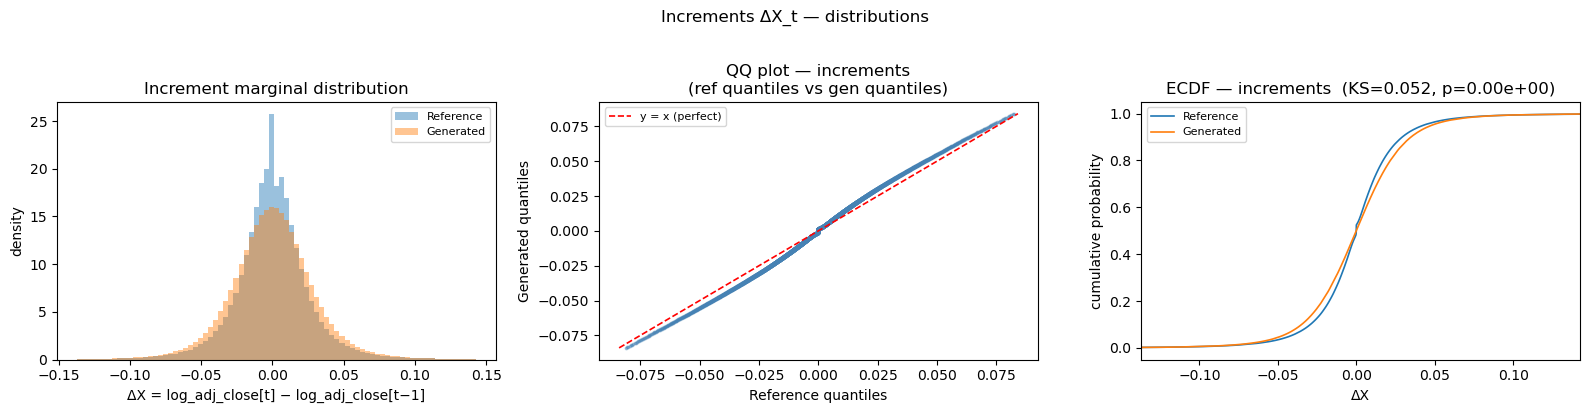

In [57]:
ref_incs = np.concatenate([np.diff(p) for p in ref_paths if len(p) > 1])
gen_incs = np.concatenate([np.diff(p) for p in gen_paths if len(p) > 1])

ks_stat_inc, ks_p_inc = scipy_stats.ks_2samp(ref_incs, gen_incs)
print(f"Increments KS statistic = {ks_stat_inc:.4f}  |  p-value = {ks_p_inc:.4e}")

combined_inc = np.concatenate([ref_incs, gen_incs])
lo_i, hi_i  = np.quantile(combined_inc, [0.002, 0.998])
bins_i      = np.linspace(lo_i, hi_i, 80)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Histogram / density
ax = axes[0]
ax.hist(ref_incs, bins=bins_i, density=True, alpha=0.45, label="Reference", color="tab:blue")
ax.hist(gen_incs, bins=bins_i, density=True, alpha=0.45, label="Generated", color="tab:orange")
ax.set_title("Increment marginal distribution")
ax.set_xlabel("ΔX = log_adj_close[t] − log_adj_close[t−1]")
ax.set_ylabel("density")
ax.legend(fontsize=8)

# (b) Empirical QQ plot
ax = axes[1]
n_q  = min(len(ref_incs), len(gen_incs), 5_000)
probs = np.linspace(0.01, 0.99, n_q)
q_ref_i = np.quantile(ref_incs, probs)
q_gen_i = np.quantile(gen_incs, probs)
ax.scatter(q_ref_i, q_gen_i, s=3, alpha=0.4, color="steelblue")
lims_i = [min(q_ref_i.min(), q_gen_i.min()), max(q_ref_i.max(), q_gen_i.max())]
ax.plot(lims_i, lims_i, "r--", linewidth=1.2, label="y = x (perfect)")
ax.set_title("QQ plot — increments\n(ref quantiles vs gen quantiles)")
ax.set_xlabel("Reference quantiles")
ax.set_ylabel("Generated quantiles")
ax.legend(fontsize=8)

# (c) ECDF
ax = axes[2]
for vals, label, color in [
    (ref_incs, "Reference", "tab:blue"),
    (gen_incs, "Generated", "tab:orange")
]:
    s = np.sort(vals)
    ax.plot(s, np.arange(1, len(s) + 1) / len(s), label=label, linewidth=1.2)
ax.set_xlim(lo_i, hi_i)
ax.set_title(f"ECDF — increments  (KS={ks_stat_inc:.3f}, p={ks_p_inc:.2e})")
ax.set_xlabel("ΔX")
ax.set_ylabel("cumulative probability")
ax.legend(fontsize=8)

plt.suptitle("Increments ΔX_t — distributions", y=1.02)
plt.tight_layout()
plt.show()

## 5. Sample paths

Visual check: do the shapes, scale, and fan-out look alike?

Reference paths may be longer; if so, a random window of the generated-path length is
extracted (using `SEED`) for a fair apples-to-apples visual.

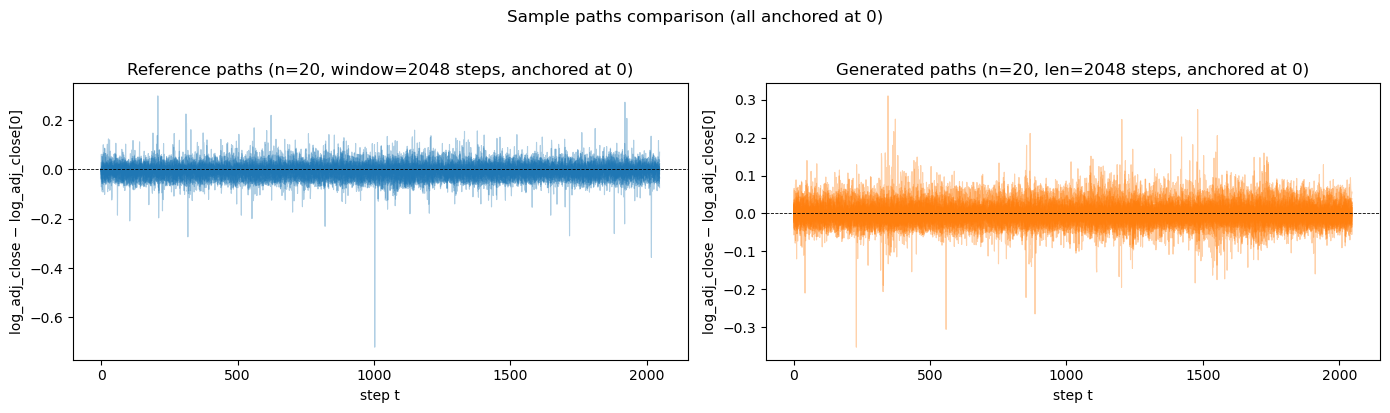

In [58]:
N_SHOW   = 20
GEN_LEN  = int(np.median(gen_lens))   # typical generated path length

# Sample random paths from each dataset
ref_idx = rng.choice(len(ref_paths), size=min(N_SHOW, len(ref_paths)), replace=False)
gen_idx = rng.choice(len(gen_paths), size=min(N_SHOW, len(gen_paths)), replace=False)

def extract_window(path: np.ndarray, window_len: int, rng: np.random.Generator) -> np.ndarray:
    """Extract a random window of `window_len` from `path`."""
    if len(path) <= window_len:
        return path
    start = rng.integers(0, len(path) - window_len + 1)
    return path[start : start + window_len]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

# Reference
ax = axes[0]
for i in ref_idx:
    p = extract_window(ref_paths[i], GEN_LEN, rng)
    p = p - p[0]   # anchor at 0
    ax.plot(np.arange(len(p)), p, alpha=0.35, linewidth=0.8, color="tab:blue")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title(f"Reference paths (n={len(ref_idx)}, window={GEN_LEN} steps, anchored at 0)")
ax.set_xlabel("step t")
ax.set_ylabel("log_adj_close − log_adj_close[0]")

# Generated
ax = axes[1]
for i in gen_idx:
    p = gen_paths[i]
    p = p - p[0]   # anchor at 0
    ax.plot(np.arange(len(p)), p, alpha=0.35, linewidth=0.8, color="tab:orange")
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title(f"Generated paths (n={len(gen_idx)}, len={GEN_LEN} steps, anchored at 0)")
ax.set_xlabel("step t")
ax.set_ylabel("log_adj_close − log_adj_close[0]")

plt.suptitle("Sample paths comparison (all anchored at 0)", y=1.02)
plt.tight_layout()
plt.show()

## 6. Autocorrelation: levels vs increments

**Rationale**:
- *Levels*: log-price paths should show high persistence (ACF ≈ 1, slow decay).
- *Increments*: log-returns should be nearly i.i.d. (ACF ≈ 0 at all lags ≥ 1).

We average ACFs across multiple paths for a stable estimate.  
For reference paths longer than `GEN_LEN` we extract the first `GEN_LEN` steps.

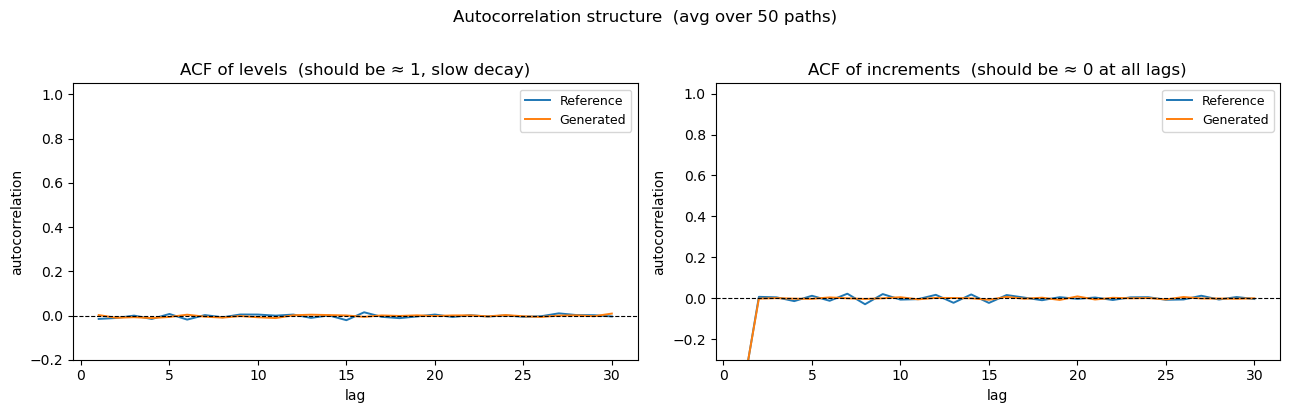

Ref  level  ACF at lag-1: -0.016  |  Gen  level  ACF at lag-1: 0.002
Ref  inc    ACF at lag-1: -0.506  |  Gen  inc    ACF at lag-1: -0.498


In [59]:
N_ACF_PATHS = min(50, len(ref_paths), len(gen_paths))
LAGS        = min(30, GEN_LEN // 2)

def mean_acf_across_paths(
    paths: list[np.ndarray],
    n_paths: int,
    lags: int,
    use_diff: bool = False,
    max_len: int | None = None,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """Average ACF (lags 1..lags) across up to `n_paths` paths."""
    indices = (
        rng.choice(len(paths), size=n_paths, replace=False)
        if rng is not None
        else np.arange(min(n_paths, len(paths)))
    )
    acfs = []
    for i in indices:
        x = paths[i]
        if max_len is not None and len(x) > max_len:
            x = x[:max_len]   # align to generated path length
        if use_diff:
            x = np.diff(x)
        if len(x) <= lags:
            continue
        acfs.append(sm_acf(x, nlags=lags, fft=True)[1:])   # skip lag-0 (=1)
    return np.mean(acfs, axis=0) if acfs else np.zeros(lags)

lag_axis = np.arange(1, LAGS + 1)

ref_acf_lev = mean_acf_across_paths(ref_paths, N_ACF_PATHS, LAGS,
                                    use_diff=False, max_len=GEN_LEN, rng=rng)
gen_acf_lev = mean_acf_across_paths(gen_paths, N_ACF_PATHS, LAGS,
                                    use_diff=False, max_len=None, rng=rng)
ref_acf_inc = mean_acf_across_paths(ref_paths, N_ACF_PATHS, LAGS,
                                    use_diff=True,  max_len=GEN_LEN, rng=rng)
gen_acf_inc = mean_acf_across_paths(gen_paths, N_ACF_PATHS, LAGS,
                                    use_diff=True,  max_len=None, rng=rng)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(lag_axis, ref_acf_lev, label="Reference", color="tab:blue",   linewidth=1.4)
ax.plot(lag_axis, gen_acf_lev, label="Generated", color="tab:orange", linewidth=1.4)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("ACF of levels  (should be ≈ 1, slow decay)")
ax.set_xlabel("lag")
ax.set_ylabel("autocorrelation")
ax.set_ylim(-0.2, 1.05)
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(lag_axis, ref_acf_inc, label="Reference", color="tab:blue",   linewidth=1.4)
ax.plot(lag_axis, gen_acf_inc, label="Generated", color="tab:orange", linewidth=1.4)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("ACF of increments  (should be ≈ 0 at all lags)")
ax.set_xlabel("lag")
ax.set_ylabel("autocorrelation")
ax.set_ylim(-0.3, 1.05)
ax.legend(fontsize=9)

plt.suptitle(f"Autocorrelation structure  (avg over {N_ACF_PATHS} paths)", y=1.02)
plt.tight_layout()
plt.show()

print(f"Ref  level  ACF at lag-1: {ref_acf_lev[0]:.3f}  |  "
      f"Gen  level  ACF at lag-1: {gen_acf_lev[0]:.3f}")
print(f"Ref  inc    ACF at lag-1: {ref_acf_inc[0]:.3f}  |  "
      f"Gen  inc    ACF at lag-1: {gen_acf_inc[0]:.3f}")

# 8. Paper's FTS evaluations metrics
These metrics are written to work on **LOG-RETURN**.

In [74]:
# ── Stylised-fact metric functions ────────────────────────────────────────────

def estimate_tail_exponent(
    returns: np.ndarray,
    x_min: float | None = None,
    x_min_quantile: float = 0.90,
    tail: str = "both",
) -> dict:
    """
    Fit CCDF of |returns| in log-log space via OLS for |r| >= x_min.
    P(|r|) ~ |r|^{-α}  ↔  CCDF(x) ~ x^{-(α-1)}  →  slope = -(α-1)  →  α = 1 - slope.

    Parameters
    ----------
    x_min          : hard threshold; if None, derived from x_min_quantile
    x_min_quantile : quantile of |r| used as lower bound for tail fit
    tail           : "both" uses |r|; "right" uses r>0; "left" uses -(r<0)
    """
    r = np.asarray(returns, dtype=float)
    r = r[np.isfinite(r)]
    if tail == "right":
        x = r[r > 0]
    elif tail == "left":
        x = -r[r < 0]
    else:
        x = np.abs(r[r != 0]) # we need different from 0 otherwise the log(0) breaks
    x = np.sort(x)

    if x_min is None:
        x_min = float(np.quantile(x, x_min_quantile))

    n_all  = len(x)
    x_tail = x[x >= x_min]
    n_tail = len(x_tail)
    if n_tail < 10:
        raise ValueError(
            f"Only {n_tail} points ≥ x_min={x_min:.5f}; lower x_min_quantile")

    # P(|r| ≥ x_tail[i]) = (n_tail − i) / n_all  (empirical CCDF, descending)
    ccdf             = np.arange(n_tail, 0, -1) / n_all
    slope, intercept = np.polyfit(np.log(x_tail), np.log(ccdf), 1)
    alpha            = 1.0 - slope   # CCDF ~ x^{-(α-1)}  →  α = 1 - slope

    return dict(alpha=alpha, x_min=x_min, n_tail=n_tail,
                x_tail=x_tail, ccdf=ccdf,
                slope=slope, intercept=intercept)


def compute_abs_return_acf(
    paths: list[np.ndarray],
    max_lag: int = 50,
    n_paths: int | None = None,
    seed_rng: np.random.Generator | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Average Corr(|r_t|, |r_{t+k}|) for k = 1..max_lag across paths.
    Assumes paths are already log-returns.
    Returns (lags, mean_acf).
    """
    n   = min(n_paths or len(paths), len(paths))
    idx = (
        seed_rng.choice(len(paths), size=n, replace=False)
        if seed_rng is not None else np.arange(n)
    )
    acfs = []
    for i in idx:
        r     = np.asarray(paths[i]).astype(float)
        abs_r = np.abs(r[np.isfinite(r)])
        if len(abs_r) <= max_lag + 1:
            continue
        acfs.append(sm_acf(abs_r, nlags=max_lag, fft=True)[1:])

    lags     = np.arange(1, max_lag + 1)
    mean_acf = np.mean(acfs, axis=0) if acfs else np.zeros(max_lag)
    return lags, mean_acf


def compute_leverage_effect(
    paths: list[np.ndarray],
    max_lag: int = 50,
) -> tuple[np.ndarray, np.ndarray]:
    """
    L(k) = E[r_t · (r_{t+k}² − r_t²)] / E[r_t²]²   per window, then averaged.
    Assumes paths are already log-returns.
    Negative L(k) for small k signals the leverage effect.
    Returns (lags, mean_L).
    """
    all_lk = []
    for path in paths:
        r = np.asarray(path).astype(float)
        r = r[np.isfinite(r)]
        n = len(r)
        if n <= max_lag:
            continue
        denom = np.mean(r ** 2)
        if denom < 1e-12:
            continue
        lk = np.array([
            np.mean(r[: n - k] * (r[k:] ** 2 - r[: n - k] ** 2))
            for k in range(1, max_lag + 1)
        ]) / denom ** 2
        all_lk.append(lk)

    lags    = np.arange(1, max_lag + 1)
    mean_lk = np.mean(all_lk, axis=0) if all_lk else np.zeros(max_lag)
    return lags, mean_lk


### 8.1 Heavy tails

Log-log CCDF of absolute returns fitted above `x_min` (grey dotted line) with OLS.  
P(|r|) ~ |r|^{−α}  ↔  CCDF(x) ~ x^{−(α−1)}; reported α = 1 − slope.  
Real equity returns typically have α ≈ 3–5 ("cubic law"). Higher α means lighter tails.

In [75]:
# ── Parameters ────────────────────────────────────────────────────────────────
HT_X_MIN_QUANTILE = 0.90    # fit power law above this quantile of |r|
HT_TAIL           = "both"  # "both" uses |r|; "right" / "left" for one-sided tail
HT_MAX_SCATTER    = 2_000   # max scatter points per dataset (subsampled on log scale)

# Compute ─────────────────────────────────────────────────────────────────────
ht_results = {}
for paths, label in [(ref_paths, "Reference"), (gen_paths, "Generated")]:
    incs = np.concatenate([p for p in paths if len(p) > 1]) #first order difference
    ht_results[label] = estimate_tail_exponent(
        incs, x_min_quantile=HT_X_MIN_QUANTILE, tail=HT_TAIL
    )

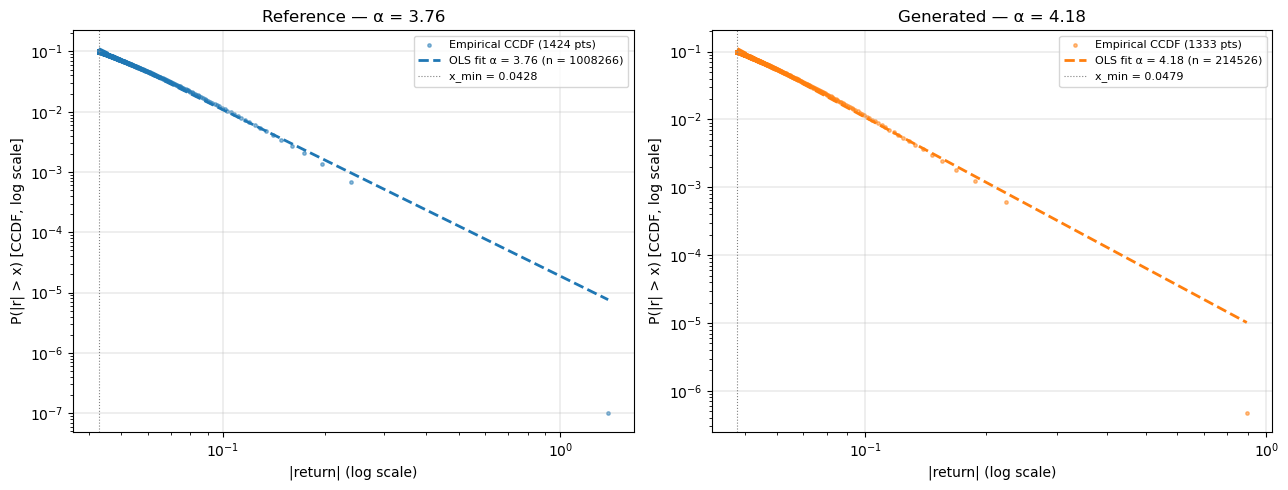

In [76]:
plt.close("all")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {"Reference": "tab:blue", "Generated": "tab:orange"}

ht_results = {}

for paths, label in [(ref_paths, "Reference"), (gen_paths, "Generated")]:
    diffs = []
    for p in paths:
        if len(p) > 1:
            d = np.diff(p)
            if d.size:
                diffs.append(d.astype(np.float32, copy=False))  # reduce memory
    if not diffs:
        raise ValueError(f"No valid increments for {label}")

    incs = np.concatenate(diffs)
    del diffs

    res = estimate_tail_exponent(
        incs, x_min_quantile=HT_X_MIN_QUANTILE, tail=HT_TAIL
    )
    del incs

    ht_results[label] = res

for ax, (label, res) in zip(axes, ht_results.items()):
    color = colors[label]

    x_tail = np.asarray(res["x_tail"])
    ccdf   = np.asarray(res["ccdf"])

    # keep only finite positive values for log-log plotting
    mask = np.isfinite(x_tail) & np.isfinite(ccdf) & (x_tail > 0) & (ccdf > 0)
    x_tail = x_tail[mask]
    ccdf   = ccdf[mask]

    if len(x_tail) == 0:
        ax.set_title(f"{label} — no valid tail points")
        continue

    n_sc = min(HT_MAX_SCATTER, len(x_tail))
    sc_idx = np.unique(np.round(
        np.logspace(0, np.log10(max(len(x_tail) - 1, 1)), n_sc)
    ).astype(int))
    sc_idx = sc_idx[sc_idx < len(x_tail)]

    ax.scatter(
        x_tail[sc_idx], ccdf[sc_idx],
        s=6, alpha=0.5, color=color,
        label=f"Empirical CCDF ({len(sc_idx)} pts)"
    )

    xmin = x_tail.min()
    xmax = x_tail.max()
    if np.isfinite(xmin) and np.isfinite(xmax) and xmin > 0 and xmax > xmin:
        x_line = np.exp(np.linspace(np.log(xmin), np.log(xmax), 300))
        ccdf_line = np.exp(res["slope"] * np.log(x_line) + res["intercept"])
        valid_line = np.isfinite(ccdf_line) & (ccdf_line > 0)

        ax.plot(
            x_line[valid_line], ccdf_line[valid_line],
            "--", color=color, linewidth=2.0,
            label=f"OLS fit α = {res['alpha']:.2f} (n = {res['n_tail']})"
        )

    if np.isfinite(res["x_min"]) and res["x_min"] > 0:
        ax.axvline(
            res["x_min"], color="grey", linewidth=0.8, linestyle=":",
            label=f"x_min = {res['x_min']:.4f}"
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"{label} — α = {res['alpha']:.2f}")
    ax.set_xlabel("|return| (log scale)")
    ax.set_ylabel("P(|r| > x) [CCDF, log scale]")
    ax.legend(fontsize=8)
    ax.grid(True, linewidth=0.3)

plt.tight_layout()
plt.show()
plt.close(fig)

### 8.2 Volatility clustering

Autocorrelation of **absolute returns** Corr(|r_t|, |r_{t+k}|) for k = 1 … max_lag.  
Real log-returns show slowly decaying positive ACF of |r_t| (ARCH/GARCH effect).  
i.i.d. noise would give ACF ≈ 0 at all lags.

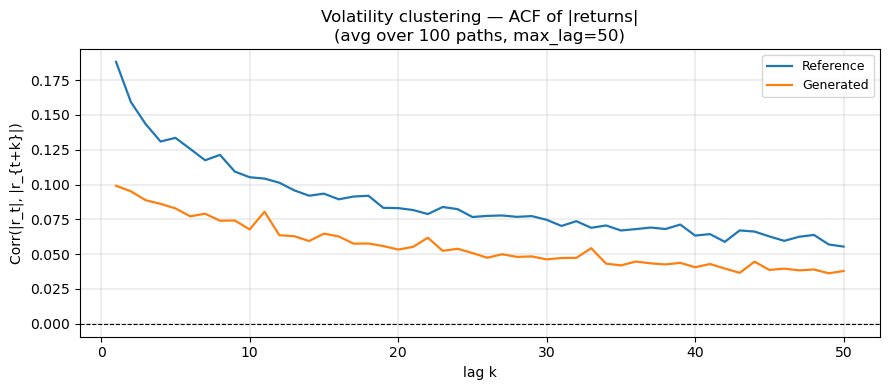

Ref  ACF(|r|) at lag 1 : 0.1882  (>0 → clustering present)
Gen  ACF(|r|) at lag 1 : 0.0991  (>0 → clustering present)


In [77]:
# ── Parameters ────────────────────────────────────────────────────────────────
VC_MAX_LAG = 50
VC_N_PATHS = min(100, len(ref_paths), len(gen_paths))

# Compute ─────────────────────────────────────────────────────────────────────
ref_vc_lags, ref_vc_acf = compute_abs_return_acf(
    ref_paths, max_lag=VC_MAX_LAG, n_paths=VC_N_PATHS, seed_rng=rng)
gen_vc_lags, gen_vc_acf = compute_abs_return_acf(
    gen_paths, max_lag=VC_MAX_LAG, n_paths=VC_N_PATHS, seed_rng=rng)

# Plot ────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ref_vc_lags, ref_vc_acf, color="tab:blue",   linewidth=1.6, label="Reference")
ax.plot(gen_vc_lags, gen_vc_acf, color="tab:orange", linewidth=1.6, label="Generated")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("lag k")
ax.set_ylabel("Corr(|r_t|, |r_{t+k}|)")
ax.set_title(
    f"Volatility clustering — ACF of |returns|\n"
    f"(avg over {VC_N_PATHS} paths, max_lag={VC_MAX_LAG})"
)
ax.legend(fontsize=9)
ax.grid(True, linewidth=0.3)
plt.tight_layout()
plt.show()

print(f"Ref  ACF(|r|) at lag 1 : {ref_vc_acf[0]:.4f}  (>0 → clustering present)")
print(f"Gen  ACF(|r|) at lag 1 : {gen_vc_acf[0]:.4f}  (>0 → clustering present)")

### 8.3 Leverage effect

L(k) = E[r_t (r_{t+k}² − r_t²)] / E[r_t²]²   computed per window and averaged across windows.  
Negative L(k) for small k means past negative returns predict higher future volatility (leverage).  
Note: log-returns here are `np.diff(log_adj_close)`, i.e. the increments used throughout.

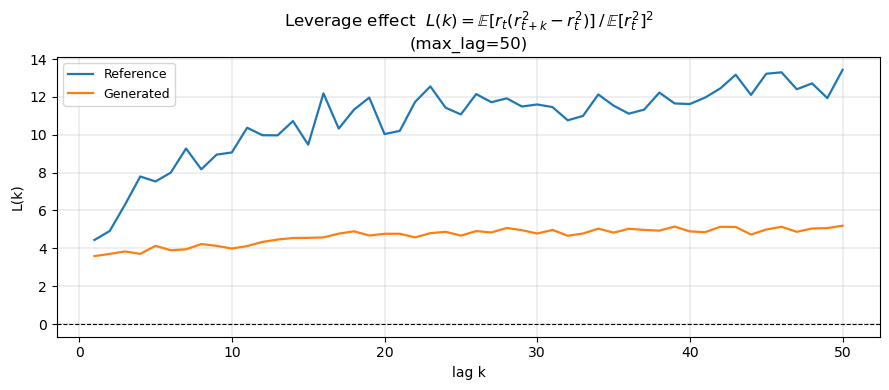

Ref  L(1) = 4.439967  (negative → leverage effect present)
Gen  L(1) = 3.588729  (negative → leverage effect present)


In [78]:
# ── Parameters ────────────────────────────────────────────────────────────────
LE_MAX_LAG = 50

# Compute ─────────────────────────────────────────────────────────────────────
ref_le_lags, ref_le = compute_leverage_effect(ref_paths, max_lag=LE_MAX_LAG)
gen_le_lags, gen_le = compute_leverage_effect(gen_paths, max_lag=LE_MAX_LAG)

# Plot ────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ref_le_lags, ref_le, color="tab:blue",   linewidth=1.6, label="Reference")
ax.plot(gen_le_lags, gen_le, color="tab:orange", linewidth=1.6, label="Generated")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("lag k")
ax.set_ylabel("L(k)")
ax.set_title(
    r"Leverage effect  $L(k) = \mathbb{E}[r_t(r_{t+k}^2 - r_t^2)] \,/\, \mathbb{E}[r_t^2]^2$"
    f"\n(max_lag={LE_MAX_LAG})"
)
ax.legend(fontsize=9)
ax.grid(True, linewidth=0.3)
plt.tight_layout()
plt.show()

print(f"Ref  L(1) = {ref_le[0]:.6f}  (negative → leverage effect present)")
print(f"Gen  L(1) = {gen_le[0]:.6f}  (negative → leverage effect present)")

## 7. Interpretation guide

| Test | Passing | Failing |
|------|---------|--------|
| **Level KS** (§3) | p > 0.05; QQ on diagonal | S-curve in QQ; large KS stat |
| **Increment KS** (§4) | p > 0.05; QQ on diagonal | Tail mismatch (fat tails not reproduced) |
| **Sample paths** (§5) | Similar scale, fan-out, no collapse | Paths cluster / diverge / show periodicity |
| **Level ACF** (§6) | High persistence (ACF ≈ 1, slow decay) | Geometric decay → AR-like collapse |
| **Increment ACF** (§6) | ACF ≈ 0 at all lags ≥ 1 | Positive ACF → spurious momentum |

**Note on fat tails**: real log-returns have excess kurtosis > 0.  
A model that reproduces the increment std but not the kurtosis has learned the scale but
not the tail structure — visible as an S-curve on the increment QQ plot.